In [1]:
from training_loop import *
from transformer import TransformerArchParams

def try_hyperparameters(adamw_params: AdamWParams, checkpoint_root, total_tokens_processed: int = 327_680_000, arch: TransformerArchParams = TransformerArchParams()):
    tiny_stories_params = TransformerParams(
        vocab_size = 10000,
        context_length = 256,
        num_layers = 4,
        d_model = 512,
        num_heads = 16,
        d_ff = 1344 if not arch.use_silu else 2048,
        theta = 10000
    )
    batch_size = 48
    num_iterations = total_tokens_processed // (batch_size * tiny_stories_params.context_length)
    print(f"Total iterations: {num_iterations}")
    train_model(
        train_data_path='../data/TinyStoriesV2-GPT4-train.dat',
        val_data_path='../data/TinyStoriesV2-GPT4-valid.dat',
        params=tiny_stories_params,
        adamw_params=adamw_params,
        batch_size=batch_size,
        num_iterations=num_iterations,
        log_interval=25,
        checkpoint_interval=num_iterations+1,
        compile = True,
        checkpoint_root=checkpoint_root,
        dtype=torch.float32,
        device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    )


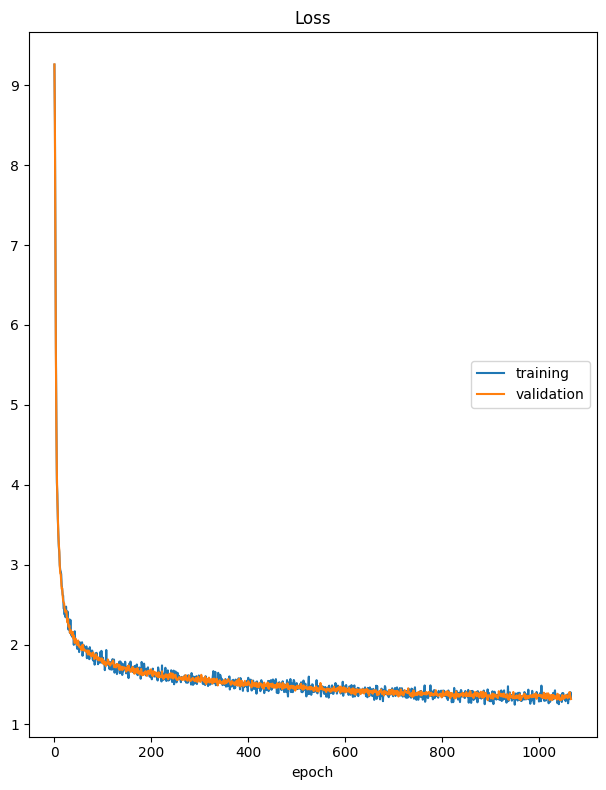

Loss
	training         	 (min:    1.248, max:    9.258, cur:    1.328)
	validation       	 (min:    1.304, max:    9.262, cur:    1.318)
[26651/26666] Loss: 1.3282 | Val Loss: 1.3181
[26651/26666]
[26652/26666]
[26653/26666]
[26654/26666]
[26655/26666]
[26656/26666]
[26657/26666]
[26658/26666]
[26659/26666]
[26660/26666]
[26661/26666]
[26662/26666]
[26663/26666]
[26664/26666]
[26665/26666]
[26666/26666]


In [2]:
try_hyperparameters(AdamWParams(1e-3, 0.01, (0.9, 0.999), 1e-8, 1e-4, 0.02, 1.0), '../data/TinyStoriesV2-GPT4-checkpoint-base', 327_680_000, TransformerArchParams())

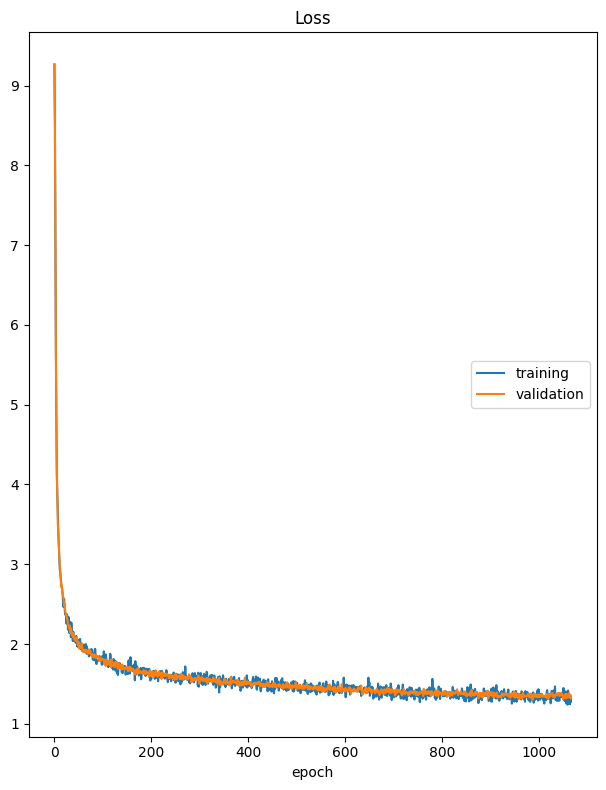

Loss
	training         	 (min:    1.240, max:    9.263, cur:    1.278)
	validation       	 (min:    1.305, max:    9.266, cur:    1.320)
[26651/26666] Loss: 1.2776 | Val Loss: 1.3199
[26651/26666]
[26652/26666]
[26653/26666]
[26654/26666]
[26655/26666]
[26656/26666]
[26657/26666]
[26658/26666]
[26659/26666]
[26660/26666]
[26661/26666]
[26662/26666]
[26663/26666]
[26664/26666]
[26665/26666]
[26666/26666]


In [3]:
try_hyperparameters(AdamWParams(1e-3, 0.01, (0.9, 0.999), 1e-8, 1e-4, 0.02, 1.0), '../data/TinyStoriesV2-GPT4-checkpoint-remove_rmsnorm', 327_680_000, TransformerArchParams(remove_rmsnorm=True))

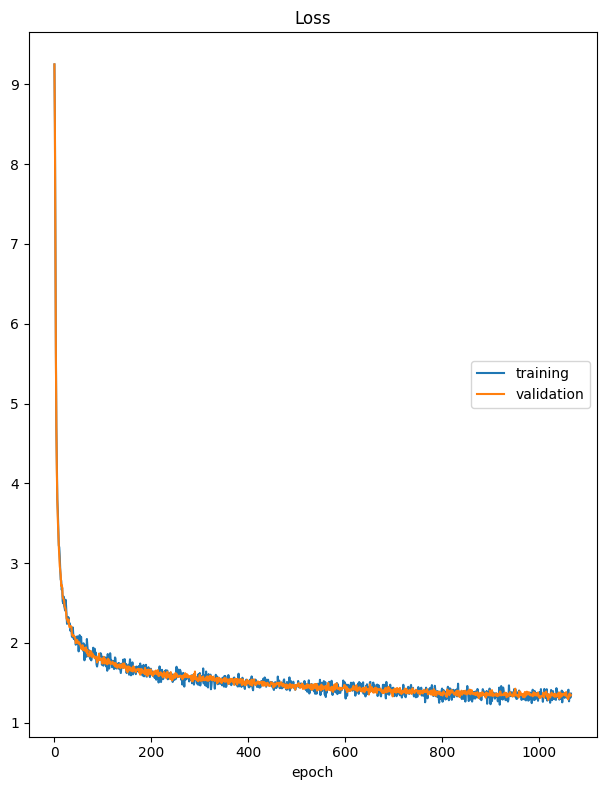

Loss
	training         	 (min:    1.225, max:    9.251, cur:    1.365)
	validation       	 (min:    1.287, max:    9.252, cur:    1.346)
[26651/26666] Loss: 1.3647 | Val Loss: 1.3456
[26651/26666]
[26652/26666]
[26653/26666]
[26654/26666]
[26655/26666]
[26656/26666]
[26657/26666]
[26658/26666]
[26659/26666]
[26660/26666]
[26661/26666]
[26662/26666]
[26663/26666]
[26664/26666]
[26665/26666]
[26666/26666]


In [4]:
try_hyperparameters(AdamWParams(1e-3, 0.01, (0.9, 0.999), 1e-8, 1e-4, 0.02, 1.0), '../data/TinyStoriesV2-GPT4-checkpoint-post_norm', 327_680_000, TransformerArchParams(post_norm=True))

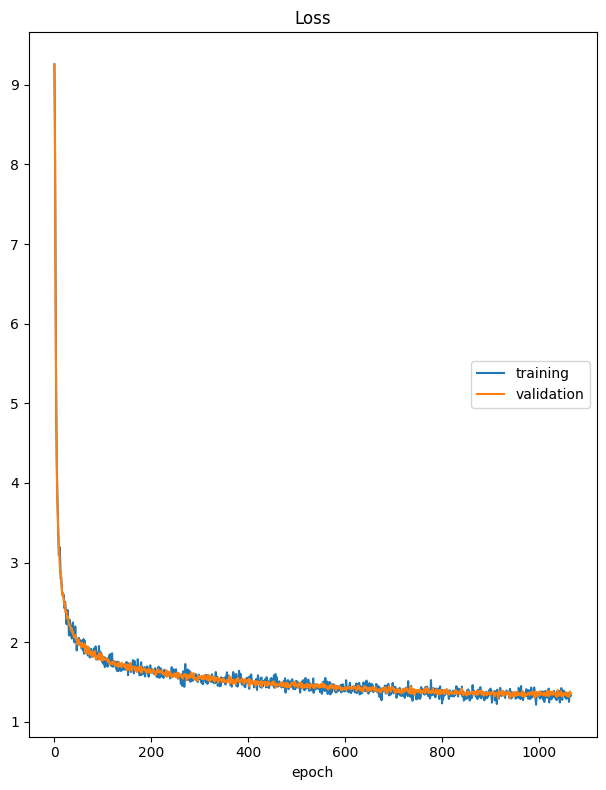

Loss
	training         	 (min:    1.215, max:    9.258, cur:    1.329)
	validation       	 (min:    1.293, max:    9.257, cur:    1.354)
[26651/26666] Loss: 1.3291 | Val Loss: 1.3544
[26651/26666]
[26652/26666]
[26653/26666]
[26654/26666]
[26655/26666]
[26656/26666]
[26657/26666]
[26658/26666]
[26659/26666]
[26660/26666]
[26661/26666]
[26662/26666]
[26663/26666]
[26664/26666]
[26665/26666]
[26666/26666]


In [5]:
try_hyperparameters(AdamWParams(1e-3, 0.01, (0.9, 0.999), 1e-8, 1e-4, 0.02, 1.0), '../data/TinyStoriesV2-GPT4-checkpoint-use_nope', 327_680_000, TransformerArchParams(use_nope=True))

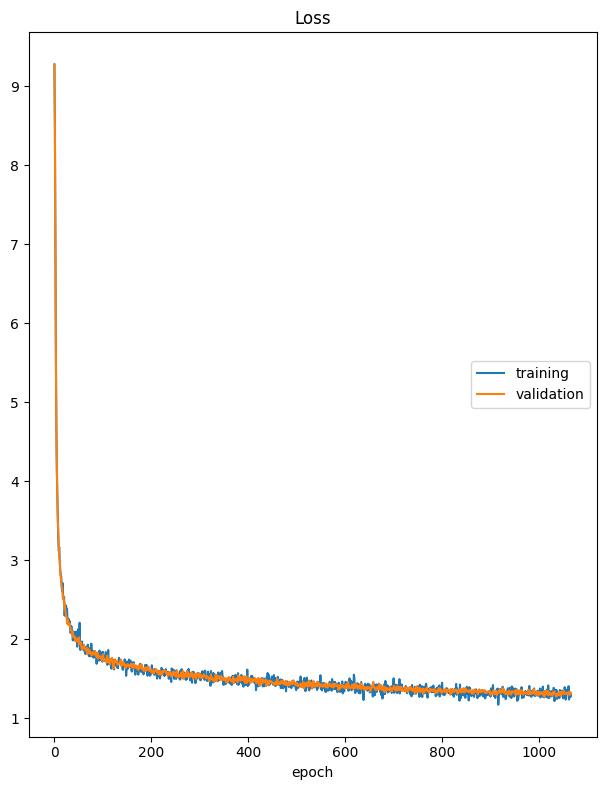

Loss
	training         	 (min:    1.172, max:    9.278, cur:    1.308)
	validation       	 (min:    1.273, max:    9.270, cur:    1.312)
[26651/26666] Loss: 1.3079 | Val Loss: 1.3116
[26651/26666]
[26652/26666]
[26653/26666]
[26654/26666]
[26655/26666]
[26656/26666]
[26657/26666]
[26658/26666]
[26659/26666]
[26660/26666]
[26661/26666]
[26662/26666]
[26663/26666]
[26664/26666]
[26665/26666]
[26666/26666]


In [6]:
try_hyperparameters(AdamWParams(1e-3, 0.01, (0.9, 0.999), 1e-8, 1e-4, 0.02, 1.0), '../data/TinyStoriesV2-GPT4-checkpoint-use_silu', 327_680_000, TransformerArchParams(use_silu=True))